## Tokenization Compression

In [1]:
import tiktoken
import urllib.request
import matplotlib.pyplot as plt

enc = tiktoken.get_encoding("cl100k_base")

books = {
    "Moby Dick":  "https://www.gutenberg.org/files/2701/2701-0.txt",
    "Frankenstein": "https://www.gutenberg.org/files/84/84-0.txt",
    "Alice in Wonderland": "https://www.gutenberg.org/files/11/11-0.txt"
}

book_texts = {}
for name, url in books.items():
    with urllib.request.urlopen(url) as f:
        book_texts[name] = f.read().decode("utf-8")
    print(f"Downloaded: {name}")

Downloaded: Moby Dick
Downloaded: Frankenstein
Downloaded: Alice in Wonderland


In [2]:
for name, text in book_texts.items():
    # Original size
    char_count = len(text)
    
    # Token count
    tokens = enc.encode(text)
    token_count = len(tokens)
    
    # Compression ratio
    ratio = char_count / token_count
    
    print(f"{name}")
    print(f"  Characters: {char_count:,}")
    print(f"  Tokens:     {token_count:,}")
    print(f"  Ratio:      {ratio:.2f} chars per token")
    print()

Moby Dick
  Characters: 1,219,043
  Tokens:     307,614
  Ratio:      3.96 chars per token

Frankenstein
  Characters: 419,434
  Tokens:     98,003
  Ratio:      4.28 chars per token

Alice in Wonderland
  Characters: 144,696
  Tokens:     36,958
  Ratio:      3.92 chars per token



In [3]:
import zlib

for name, text in book_texts.items():
    # Original bytes
    original_bytes = text.encode("utf-8")
    
    # ZIP compressed bytes
    compressed_bytes = zlib.compress(original_bytes)
    
    # Token "compression"
    tokens = enc.encode(text)
    
    token_bytes = len(tokens) * 2
    
    zip_ratio   = len(original_bytes) / len(compressed_bytes)
    token_ratio = len(original_bytes) / token_bytes
    
    print(f"{name}")
    print(f"  ZIP compression ratio:   {zip_ratio:.2f}x")
    print(f"  Token compression ratio: {token_ratio:.2f}x")
    print()

Moby Dick
  ZIP compression ratio:   2.46x
  Token compression ratio: 2.01x

Frankenstein
  ZIP compression ratio:   2.62x
  Token compression ratio: 2.15x

Alice in Wonderland
  ZIP compression ratio:   2.82x
  Token compression ratio: 2.05x



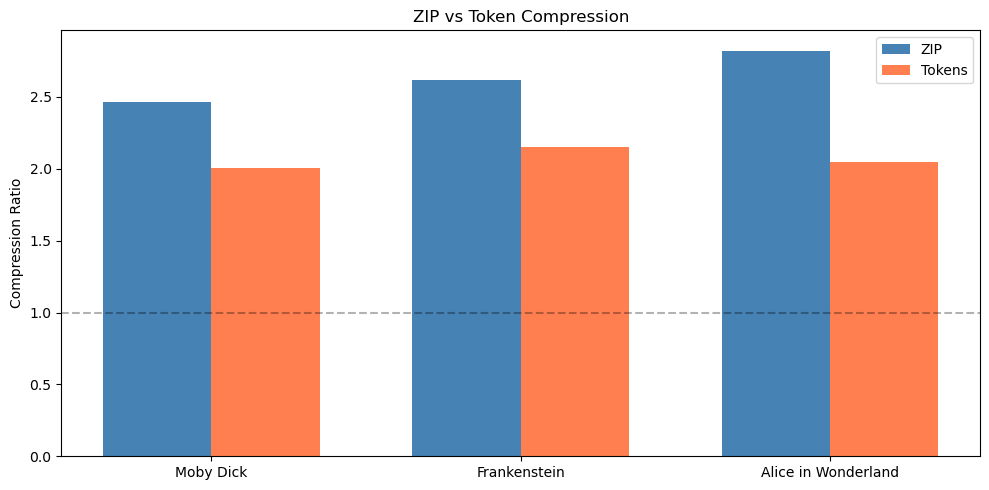

In [4]:
import numpy as np

names = list(book_texts.keys())
zip_ratios   = []
token_ratios = []

for name, text in book_texts.items():
    original_bytes   = text.encode("utf-8")
    compressed_bytes = zlib.compress(original_bytes)
    tokens           = enc.encode(text)
    
    zip_ratios.append(len(original_bytes) / len(compressed_bytes))
    token_ratios.append(len(original_bytes) / (len(tokens) * 2))

x     = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, zip_ratios,   width, label="ZIP",    color="steelblue")
ax.bar(x + width/2, token_ratios, width, label="Tokens", color="coral")

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Compression Ratio")
ax.set_title("ZIP vs Token Compression")
ax.legend()
ax.axhline(y=1, color="black", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

* Tokenization acts as a **side effect compression**, typically reducing text size by about **~2x**.

* Traditional compression methods like **ZIP** achieve around **~2.5x compression**, making them more efficient for pure compression.

* The main goal of tokenization is **not compression**, but to **preserve meaning in a structured way** that models can understand and process effectively.
